In [1]:
import pandas as pd
import numpy as np
import os
import glob
import shutil
import scipy.stats as stats
import scipy.signal as signal
from scipy.ndimage import gaussian_filter1d
import sys

In [2]:
import Waveform_Isolation as WI

# Recursively find all CSV files in the Simulated_Waveforms directory
search_path = os.path.join('Simulated_Waveforms', '*.csv')
channel_files = glob.glob(search_path)

results = [] # This list will be passed by reference to accumulate results

if not channel_files:
    print(f"No channel files found in {search_path}")
    sys.exit()

# Read all channels into a dictionary of dataframes, to be used later
# At the same time, process each channel and isolate the waveforms
print(f"Loading {len(channel_files)} channel files into memory...")
channel_dataframes = {}
for filepath in channel_files:
    filename = os.path.basename(filepath)
    try:
        # Load the CSV file without headers
        df = pd.read_csv(filepath, header=None)
        WI.process_file(df, filepath, results, WI.PRE_TRIGGER_SAMPLES, WI.POST_TRIGGER_SAMPLES)
        channel_dataframes[filename] = df
    except Exception as e:
        print(f"  Error loading {filename}: {e}")
        
if not channel_dataframes:
    print("No dataframes loaded. Exiting.")
    sys.exit()

    # After processing all files, save the accumulated results to a single CSV
if results:
    indices_df = pd.DataFrame(results)
    indices_df.to_csv('Waveform_Analysis.csv', index=False)
    print(f"\nSuccessfully saved {len(results)} waveform entries to 'Waveform_Indices.csv'")
else:
    print("\nNo waveforms isolated. Summary file not created.")

Loading 4 channel files into memory...
Processed Ch1.csv -> Saved 31 waveforms
Processed Ch2.csv -> Saved 32 waveforms
Processed Ch3.csv -> Saved 33 waveforms
Processed Ch4.csv -> Saved 33 waveforms

Successfully saved 129 waveform entries to 'Waveform_Indices.csv'


In [3]:
import Envelope_Analysis as EA

EA.cluster_waveforms_2(channel_dataframes)

In [4]:
import Wavelet_Decomposition as WD
# 2. Pre-load channel files into memory


# 3. Process each isolated waveform
print(f"Extracting features for {len(indices_df)} waveforms...")

results = []

for i, row in indices_df.iterrows():
    filename = row['input filename']
    start_idx = int(row['start idx'])
    end_idx = int(row['end idx'])
    count = row['count']
    
    # Extract signal from the pre-loaded dataframes
    try:
        df = channel_dataframes[filename]
        signal_segment = df.iloc[start_idx:end_idx, 1].values
        
        # Extract features
        energies = WD.calculate_wavelet_energy(signal_segment)
        
        if energies is not None:
            res_row = {
                'input filename': filename,
                'count': count,
                'Energy_A5': energies[0],
                'Energy_D5': energies[1],
                'Energy_D4': energies[2],
                'Energy_D3': energies[3],
                'Energy_D2': energies[4],
                'Energy_D1': energies[5]
            }
            results.append(res_row)
            
    except Exception as e:
        print(f"Error processing {filename} #{count}: {e}")

# 4. Save results to CSV
if results:
    new_df = pd.DataFrame(results)
        
    if os.path.exists(WD.OUTPUT_FILE):
        existing_df = pd.read_csv(WD.OUTPUT_FILE)
        # Merge new results as columns. 
        # We assume 'Filename' is the common identifier for rows.
        if 'input filename' in existing_df.columns and 'count' in existing_df.columns:
            # Merge on Filename and Count to ensure rows match correctly
            # 'outer' join ensures we don't lose rows
            final_df = pd.merge(existing_df, new_df, on=['input filename', 'count'], how='outer')
        else:
            # Fallback: if keys are missing, just concatenate columns
            final_df = pd.concat([existing_df, new_df], axis=1)
        
        final_df.to_csv(WD.OUTPUT_FILE, index=False)
        print(f"Processing complete. Data appended as columns to {WD.OUTPUT_FILE}")
    else:
        new_df.to_csv(WD.OUTPUT_FILE, index=False)
        print(f"Processing complete. Data saved to {WD.OUTPUT_FILE}")
else:
    print("No features extracted.")

Extracting features for 129 waveforms...
Processing complete. Data appended as columns to Waveform_Analysis.csv


Loading data from Waveform_Analysis.csv...
Computing Principal Components...
Explained Variance by component: [8.85581394e-01 1.13881551e-01 3.12715357e-04]
Total Information Retained: 99.98%
PCA results appended to Waveform_Analysis.csv
Generating 3D Plot...


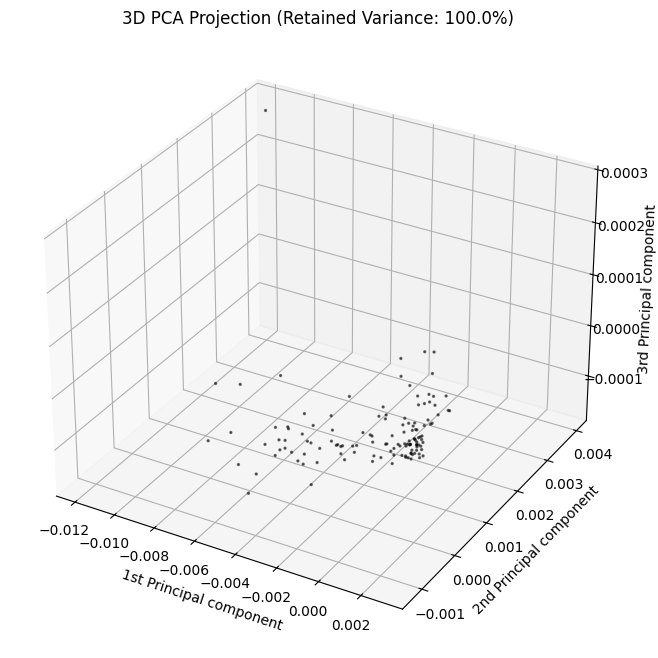

In [5]:
import Principal_Component_Analysis as pca

pca.perform_pca_and_visualize('Waveform_Analysis.csv')

In [6]:
import DBSCAN as dbscan

dbscan.perform_simple_clustering('Waveform_Analysis.csv')

Loading data from Waveform_Analysis.csv...


d:\Zee_Documents\Studies\Uni\Sem_7\KIE4002_FYP\Python\Simulated Data CSV Analysis\DBSCAN.py:130: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ch1_df['Simple PCA Feature Cluster ID'] = ch1_df['count']
d:\Zee_Documents\Studies\Uni\Sem_7\KIE4002_FYP\Python\Simulated Data CSV Analysis\DBSCAN.py:131: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ch2_df['Simple PCA Feature Cluster ID'] = 0
d:\Zee_Documents\Studies\Uni\Sem_7\KIE4002_FYP\Python\Simulated Data CSV Analysis\DBSCAN.py:132: SettingWithCopyWarning: 
A 

Simple PCA clustering complete. Data saved back to Waveform_Analysis.csv
